In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as spopt
import numpy.ma as ma
from tqdm import tqdm
import pandas as pd
import glob, os
from astropy.coordinates import SkyCoord
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.wcs import WCS
import astropy.units as u
from regions import CircleSkyRegion
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import sys
#Need this command for the _merge function for recursion
sys.setrecursionlimit(10**5)

In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Define the two coordinates
coord1 = SkyCoord(ra='21h27m39.8353800s', dec='04d19m45.634380s', frame='icrs')
coord2 = SkyCoord(ra='21h27m39.8880000s', dec='04d21m00.360000s', frame='icrs')

# Calculate angular separation
sep = coord1.separation(coord2)

# Convert to arcminutes
sep_arcmin = sep.to(u.arcmin)

print(f"Angular separation: {sep_arcmin:.6f}")

Angular separation: 1.245496 arcmin


In [2]:
def master_opener():
    """
    Opens and processes the master DataFrame from a CSV file, performs data cleaning and filtering, 
    and returns a subset of the data relevant to a specific source and telescopes.

    The function performs the following:
    - Loads the most recent `master_df` from a CSV file.
    - Adds a column for observed hours, calculated from MJD start and end times.
    - Sorts the DataFrame by observation date.
    - Filters rows for the source R147 and aliases (FRB20240114A,R240121,R240114) and specific telescopes, excluding 'Nancay'.
    - Outputs the unique set of telescope names and central frequencies for the filtered data.

    Returns:
        pd.DataFrame: A DataFrame (`df`) filtered for the specified source and telescopes.
    """
    #Opening the most recent master_df, dont forget to pull the git repo
    master_df = pd.read_csv("/home/omar/git/logs/master_df.csv", sep=",", header=0, index_col=0, \
                            na_values='NA', engine='python')

    # Filter for the desired source and telescopes
    df = master_df[(master_df["Source_Name"].isin(["R240121", "R240114", "FRB20240114A"])) &
               (master_df["Telescope"].isin(["wb", "tr", "stk", "o8"]))].copy()
    
    #### TO BE DONE
    # if dwi_import:
    #     # Import the dwingeloo database 
    #     dwi_df = pd.read_csv("DWi_273_scans_dwi_2024_V2_jan25.csv", sep=",", index_col=0, na_values='NA', engine='python')
    #     df_merged = pd.concat([df, dwi_df], ignore_index=True, sort=False)
    # else:
    #     df_merged = df
    #### TO BE DONE   

    #Adding in the observed_hours per row
    df["observed_hours"] = (df["MJD_end_time"] - df["MJD_start_time"]) * 24
    
    #Sort just because 
    df = df.sort_values(by="Obs_Date_String")

    df = df[(df["scan_name"] != "rk002")]
    
    display(df)
    
    tels = set(df["Telescope"].values)
    obs_set= set(df["Central_freq_(MHz)"].values)
    print(len(obs_set))
    print(tels)
    print(obs_set)
    
    return df

df_r147 = master_opener()

,scan_name,scan_no,Telescope,Source_Name,Obs_Date_String,MJD_start_time,RA_J2000,RA_J2000_(deg),Dec_J2000,Dec_J2000_(deg),...,bytes_in_file_header,MJD_end_time,complete_filename,Are_bytes_signed?,Polarization_order,Backend,Starting_subint,Subints_per_file,Source_Name_nancay,observed_hours
115514,pcn235,no0001,wb,R240121,2024-01-25T13:50:01,60334.576400,21:34:03.4440,323.514350,04:29:06.1800,4.485050,...,295.0,60334.586794,pcn235_wb_no0001_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249437
115515,pcn235,no0002,wb,R240121,2024-01-25T14:05:15,60334.586979,21:34:03.4440,323.514350,04:29:06.1800,4.485050,...,295.0,60334.597349,pcn235_wb_no0002_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.248882
115516,pcn235,no0003,wb,R240121,2024-01-25T14:20:27,60334.597535,21:34:03.4440,323.514350,04:29:06.1800,4.485050,...,295.0,60334.607917,pcn235_wb_no0003_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249164
115517,pcn235,no0004,wb,R240121,2024-01-25T14:35:39,60334.608090,21:34:03.4440,323.514350,04:29:06.1800,4.485050,...,295.0,60334.618472,pcn235_wb_no0004_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249164
115518,pcn235,no0005,wb,R240121,2024-01-25T14:50:51,60334.618646,21:34:03.4440,323.514350,04:29:06.1800,4.485050,...,295.0,60334.629016,pcn235_wb_no0005_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.248882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231403,p55415,no0032,wb,R240114,2025-10-08T21:19:18,60956.888403,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,60956.898784,p55415_wb_no0032_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249146
231404,p55415,no0033,wb,R240114,2025-10-08T21:34:30,60956.898958,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,60956.909339,p55415_wb_no0033_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249146
231405,p55415,no0034,wb,R240114,2025-10-08T21:49:42,60956.909514,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,60956.919883,p55415_wb_no0034_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.248855
231406,p55415,no0035,wb,R240114,2025-10-08T22:04:54,60956.920069,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,60956.930438,p55415_wb_no0035_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.248855


8
{'tr', 'stk', 'wb', 'o8'}
{4708.0, 1381.46484375, 1414.0, 1444.0, 1418.0, 332.0, 1424.0, 1271.0}


In [3]:
def pointing_filter(df):

    # Define alias mapping (you can expand this list)
    alias_map = {
        "FRB20240114A": "R240114",
        "R240121": "R240114",
        # add more aliases as needed
    }
    
    # Normalize source names
    df["Source_Name"] = df["Source_Name"].replace(alias_map)

    columns = ["Source_Name", "Obs_Date_String", "MJD_start_time","Telescope", "RA_J2000_(deg)", "Dec_J2000_(deg)"]
    
    # Drop duplicates based only on telescope + RA + Dec, but keep Source_Name
    unique_df = df.drop_duplicates(subset=["Telescope","RA_J2000_(deg)", "Dec_J2000_(deg)"]).reset_index(drop=True)
    
    # Optionally select only the columns you want to keep visible
    unique_df = unique_df[columns]

    display(unique_df)

    return unique_df

pointing_df = pointing_filter(df=df_r147)

,Source_Name,Obs_Date_String,MJD_start_time,Telescope,RA_J2000_(deg),Dec_J2000_(deg)
0,R240114,2024-01-25T13:50:01,60334.576400,wb,323.514350,4.485050
1,R240114,2024-01-27T07:52:53,60336.328391,o8,323.514350,4.485050
2,R240114,2024-01-27T11:48:17,60336.491863,tr,323.514350,4.485050
3,R240114,2024-01-29T13:00:01,60338.541678,wb,321.916200,4.350100
4,R240114,2024-01-30T09:44:15.1156,60339.405731,stk,321.916667,4.350000
5,R240114,2024-02-02T10:48:22,60342.450255,tr,321.916200,4.350100
6,R240114,2024-02-10T06:48:48,60350.283889,o8,321.916200,4.350100
7,R240114,2024-02-24T05:39:02,60364.235440,wb,321.915986,4.329509
8,R240114,2024-03-09T08:01:07,60378.334109,tr,321.916667,4.329444
9,R240114,2024-03-11T05:01:48,60380.209583,o8,321.915986,4.329509


In [60]:
def pointing(df):
    # Define the star's coordinates
    star_coord = SkyCoord("21h27m39.835s", "+04d19m45.668s", frame="icrs")

    # Set up a TAN (gnomonic) projection centered on the star
    wcs = WCS(naxis=2)
    wcs.wcs.crpix = [100, 100]
    wcs.wcs.cdelt = np.array([-0.01, 0.01])  # deg/pixel
    wcs.wcs.crval = [star_coord.ra.deg, star_coord.dec.deg]
    wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    wcs.wcs.cunit = ["deg", "deg"]

    # Create main WCS plot
    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(projection=wcs)

    # Plot star and 0.5° circle
    ax.plot(star_coord.ra.deg, star_coord.dec.deg, transform=ax.get_transform('icrs'),
            marker='*', color='red', markersize=12, label='Star Position')

    radius = 0.5 * u.deg
    circle = SphericalCircle(
        (star_coord.ra, star_coord.dec), radius,
        transform=ax.get_transform('icrs'),
        edgecolor='blue', facecolor='none', label='L-band main beam (0.5°)'
    )
    ax.add_patch(circle)

    # Plot all telescope pointings
    ax.scatter(df['RA_J2000_(deg)'], df['Dec_J2000_(deg)'],
               transform=ax.get_transform('icrs'),
               color='green', marker='s', s=20, label='Pointings')

    ax.set_xlabel('Right Ascension (J2000)')
    ax.set_ylabel('Declination (J2000)')
    ax.grid(color='gray', ls='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    # ===== Inset setup =====
    # Create inset axes anchored on the main axes
    inset_ax = inset_axes(
        ax, width="40%", height="40%",
        bbox_to_anchor=(0.0, -0.1, 0.5, 0.5),  # Adjust position manually if needed
        bbox_transform=ax.transAxes, borderpad=1
    )

    # Plot same star and pointings in inset
    inset_ax.plot(star_coord.ra.deg, star_coord.dec.deg, 
                  marker='*', color='red', markersize=8)
    inset_ax.scatter(df['RA_J2000_(deg)'], df['Dec_J2000_(deg)'],
                     color='green', marker='s', s=25)

    # Zoom around the star (±0.05° gives a clear view of close pointings)
    inset_ax.set_xlim(star_coord.ra.deg + 0.1, star_coord.ra.deg - 0.1)  # reverse RA axis
    inset_ax.set_ylim(star_coord.dec.deg - 0.1, star_coord.dec.deg + 0.1)

    # Inset formatting
    inset_ax.tick_params(axis='both', labelsize=8)
    inset_ax.grid(True, alpha=0.4)

    for axs in [ax, inset_ax]:
        for axis in ['top', 'bottom', 'left', 'right']:
            axs.spines[axis].set_linewidth(2)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1988802/2781564229.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


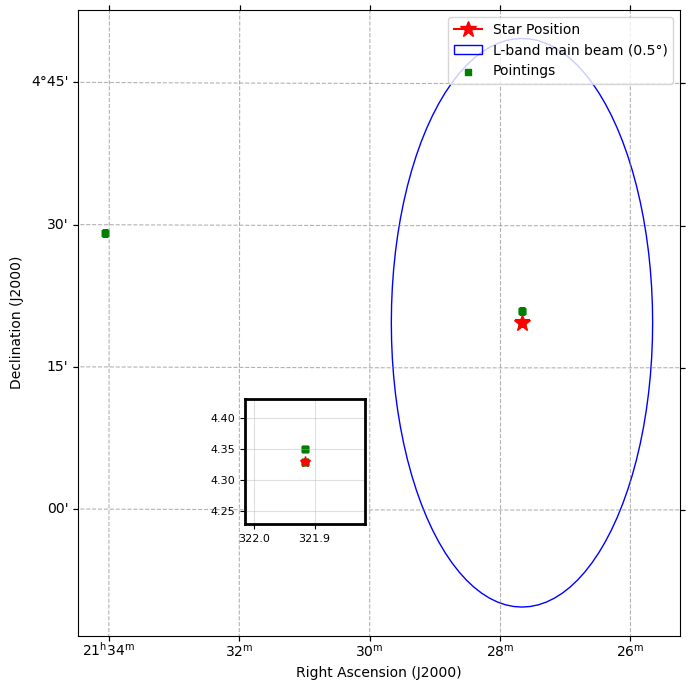

In [61]:
pointing(df=pointing_df)